# Fase 1 - Exploracion de Videojuegos

## 1. Fuente y tipo de datos
- Archivo analizado: `Video Games Sales (1980-2024) - Raw.csv`
- Ubicacion: `datasets/Video Games Sales (1980-2024) - Raw.csv`
- Tipo de dato: Tabular (CSV)
- Clasificacion de fuente: Secundaria

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

In [ ]:
# Carga de datos
df = pd.read_csv('../datasets/Video Games Sales (1980-2024) - Raw.csv')
df.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,17-09-2013,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,18-11-2014,03-01-2018
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,28-10-2002,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,17-09-2013,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,06-11-2015,14-01-2018


In [3]:
# 2. Caracteristicas basicas
rows, cols = df.shape
size_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)

print(f'Registros: {rows:,}')
print(f'Atributos: {cols}')
print(f'Tamano estimado en memoria: {size_mb:.2f} MB')
display(df.dtypes.to_frame('dtype'))

Registros: 64,016
Atributos: 14
Tamano estimado en memoria: 32.73 MB


,dtype
img,str
title,str
console,str
genre,str
publisher,str
developer,str
critic_score,float64
total_sales,float64
na_sales,float64
jp_sales,float64


In [4]:
# Completitud: nulos por columna
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df

,missing_count,missing_pct
critic_score,57338,89.57
jp_sales,57290,89.49
na_sales,51379,80.26
pal_sales,51192,79.97
other_sales,48888,76.37
last_update,46137,72.07
total_sales,45094,70.44
release_date,7051,11.01
developer,17,0.03
publisher,0,0.00


In [5]:
# Calidad de identificacion de registros
print('Titulos unicos:', df['title'].nunique())
print('Consolas unicas:', df['console'].nunique())
dupes = df.duplicated(subset=['title', 'console', 'release_date']).sum()
print('Posibles duplicados por title-console-release_date:', dupes)

Titulos unicos: 39798
Consolas unicas: 81
Posibles duplicados por title-console-release_date: 139


In [6]:
# Preparacion minima de fechas
df['release_date_parsed'] = pd.to_datetime(df['release_date'], format='%d-%m-%Y', errors='coerce')
df['release_year'] = df['release_date_parsed'].dt.year

print('Fechas parseadas correctamente:', df['release_date_parsed'].notna().sum())
print('Fechas no parseadas:', df['release_date_parsed'].isna().sum())

Fechas parseadas correctamente: 56965
Fechas no parseadas: 7051


,count
genre,
Misc,9304
Action,8557
Adventure,6260
Role-Playing,5721
Sports,5586
Shooter,5410
Platform,4001
Strategy,3685
Puzzle,3521


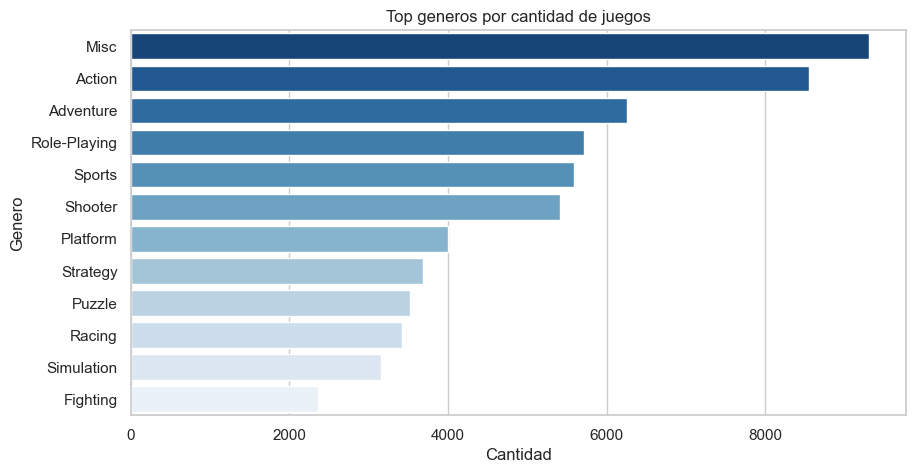

In [7]:
# Distribucion por genero
genre_top = df['genre'].value_counts().head(12)
display(genre_top.to_frame('count'))

plt.figure(figsize=(10, 5))
sns.barplot(x=genre_top.values, y=genre_top.index, palette='Blues_r')
plt.title('Top generos por cantidad de juegos')
plt.xlabel('Cantidad')
plt.ylabel('Genero')
plt.show()

,count
console,
PC,12617
PS2,3565
DS,3288
PS4,2878
PS,2707
NS,2337
XBL,2120
PSN,2004
XOne,1963


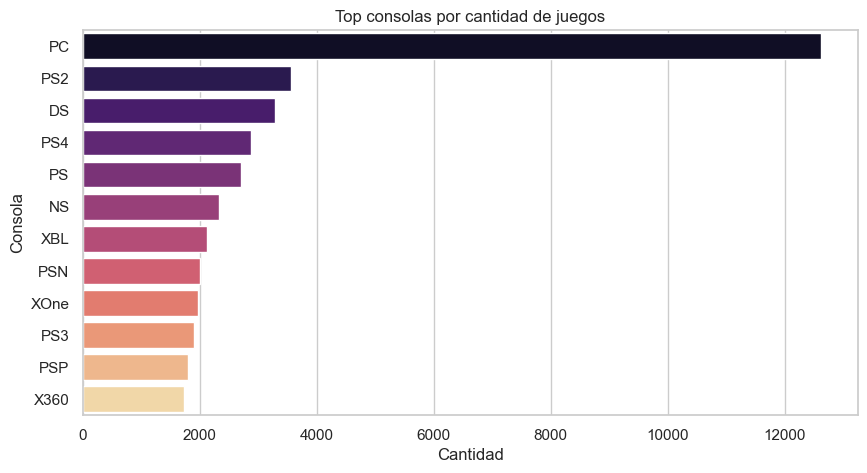

In [8]:
# Top consolas
console_top = df['console'].value_counts().head(12)
display(console_top.to_frame('count'))

plt.figure(figsize=(10, 5))
sns.barplot(x=console_top.values, y=console_top.index, palette='magma')
plt.title('Top consolas por cantidad de juegos')
plt.xlabel('Cantidad')
plt.ylabel('Consola')
plt.show()

,count,mean,std,min,25%,50%,75%,max
total_sales,18922.0,0.349113,0.807462,0.0,0.03,0.12,0.34,20.32
na_sales,12637.0,0.264740,0.494787,0.0,0.05,0.12,0.28,9.76
jp_sales,6726.0,0.102281,0.168811,0.0,0.02,0.04,0.12,2.13
pal_sales,12824.0,0.149472,0.392653,0.0,0.01,0.04,0.14,9.85
other_sales,15128.0,0.043041,0.126643,0.0,0.00,0.01,0.03,3.12


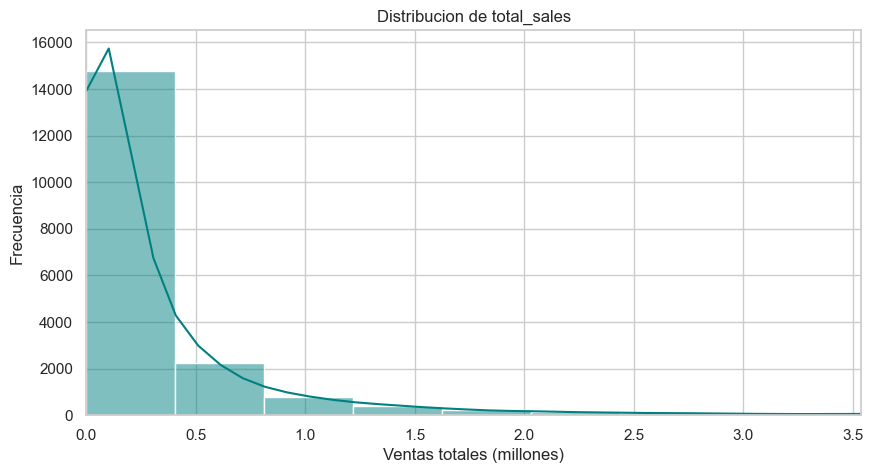

In [9]:
# Ventas totales y por region
sales_cols = ['total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales']
sales_summary = df[sales_cols].describe().T
display(sales_summary)

plt.figure(figsize=(10, 5))
sns.histplot(df['total_sales'].dropna(), bins=50, kde=True, color='teal')
plt.title('Distribucion de total_sales')
plt.xlabel('Ventas totales (millones)')
plt.ylabel('Frecuencia')
plt.xlim(0, df['total_sales'].quantile(0.99))
plt.show()

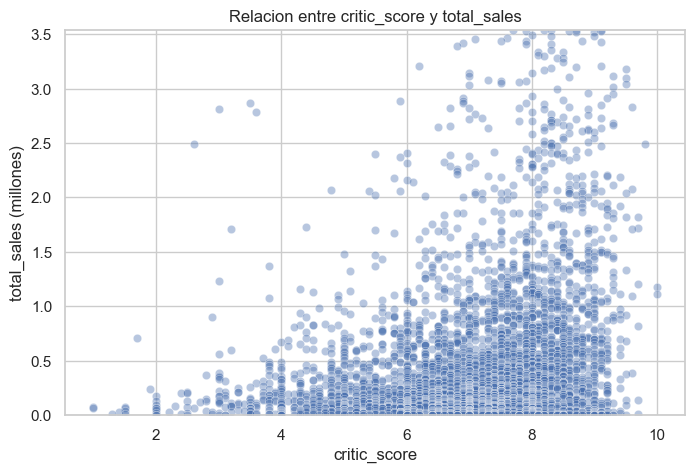

,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales
critic_score,1.000000,0.281166,0.300289,0.147448,0.246694,0.243847
total_sales,0.281166,1.000000,0.914149,0.212469,0.907421,0.859329
na_sales,0.300289,0.914149,1.000000,0.065091,0.684517,0.687512
jp_sales,0.147448,0.212469,0.065091,1.000000,0.131796,0.082653
pal_sales,0.246694,0.907421,0.684517,0.131796,1.000000,0.817030
other_sales,0.243847,0.859329,0.687512,0.082653,0.817030,1.000000


In [10]:
# Relacion entre score critico y ventas
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='critic_score', y='total_sales', alpha=0.4)
plt.title('Relacion entre critic_score y total_sales')
plt.xlabel('critic_score')
plt.ylabel('total_sales (millones)')
plt.ylim(0, df['total_sales'].quantile(0.99))
plt.show()

corr = df[['critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales']].corr(numeric_only=True)
display(corr)

,count
release_year,
2005.0,1810
2006.0,2096
2007.0,2525
2008.0,2936
2009.0,4360
2010.0,3586
2011.0,3386
2012.0,1584
2013.0,1740


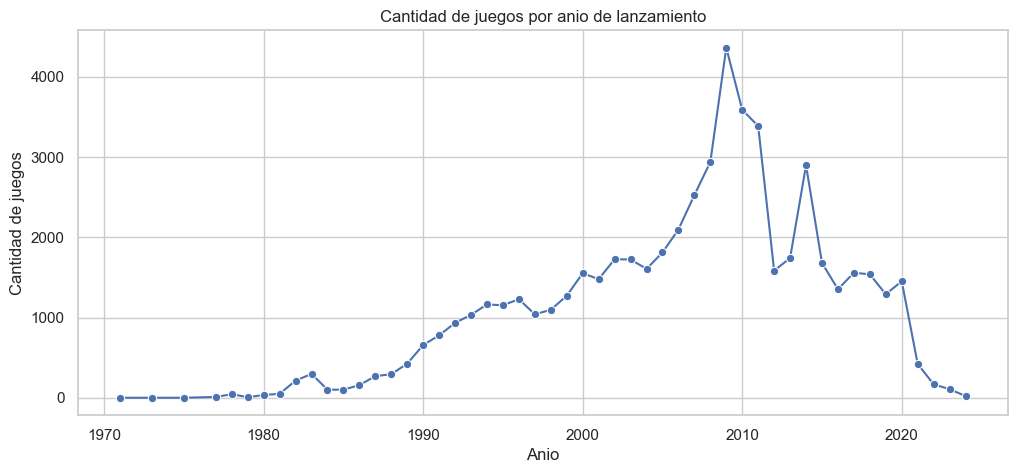

In [11]:
# Serie temporal de lanzamientos
games_by_year = df['release_year'].value_counts().sort_index()
display(games_by_year.tail(20).to_frame('count'))

plt.figure(figsize=(12, 5))
sns.lineplot(x=games_by_year.index, y=games_by_year.values, marker='o')
plt.title('Cantidad de juegos por anio de lanzamiento')
plt.xlabel('Anio')
plt.ylabel('Cantidad de juegos')
plt.show()

## 3. Nivel de documentacion disponible

El dataset tiene nombres de columnas claros y metricas reconocibles para ventas por region,
puntaje critico y metadatos de juegos. La columna de fecha requiere limpieza por valores faltantes
y formato, pero en general la estructura es interpretable y util para analisis.

## 4. Posibles aplicaciones

1. Analizar tendencias historicas de lanzamientos por genero y consola.
2. Estudiar relacion entre recepcion critica y ventas globales.
3. Comparar desempeno comercial por regiones (NA, JP, PAL, Other).
4. Identificar publishers y developers con mayor impacto en ventas.

## 5. Evaluacion rapida para seleccion

- Completitud: Media (faltantes en `critic_score`, `release_date`, `last_update`).
- Relevancia: Alta para analisis de mercado de videojuegos.
- Documentacion: Media-Alta por nombres de variables intuitivos.
- Manejabilidad: Alta (dataset tabular, escala manejable en notebook).

## Documentacion final (Fase 1)

### Hallazgos cuantitativos del analisis
- Registros: **64,016**.
- Atributos: **14**.
- Nulos principales: `critic_score` (57,338), `jp_sales` (57,290), `na_sales` (51,379), `pal_sales` (51,192), `other_sales` (48,888), `last_update` (46,137).
- Generos mas frecuentes: `Misc` (9,304), `Action` (8,557), `Adventure` (6,260), `Role-Playing` (5,721), `Sports` (5,586).
- Consolas mas frecuentes: `PC` (12,617), `PS2` (3,565), `DS` (3,288), `PS4` (2,878), `PS` (2,707).
- `total_sales`: media **0.349**, mediana **0.12**, maximo **20.32** (distribucion sesgada a la derecha).
- Correlacion `critic_score` vs `total_sales`: **0.281** (positiva debil-moderada).

### Interpretacion
- El dataset es amplio y relevante para analisis de mercado (ventas por plataforma, genero y region).
- La completitud es el principal reto: existen faltantes altos en variables de ventas regionales y puntaje critico.
- Aun con los nulos, la base es manejable para EDA descriptivo y para construir hipotesis de negocio.

### Cumplimiento de criterios de Fase 1 para esta base
1. **Fuente y tipo de datos**: Cumple (tabular, fuente secundaria).
2. **Caracteristicas basicas**: Cumple (registros, atributos y tamano evaluados).
3. **Nivel de documentacion y aplicaciones**: Cumple (variables intuitivas para analisis comercial).
4. **Completitud, relevancia y manejabilidad**: Cumple parcialmente en completitud (faltantes altos), pero cumple en relevancia y manejabilidad.